In [12]:
import pandas as pd

df = pd.read_csv('datatran2025.csv', sep=';', encoding='latin-1')
df.head()
# df.columns.tolist()
df

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,...,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,...,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,...,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47187,719592,2025-08-30,sábado,11:10:00,ES,101,"295,6",CARIACICA,Objeto estático sobre o leito carroçável,Tombamento,...,0,0,0,1,1,"-20,33713308","-40,40256354",SPRF-ES,DEL01-ES,UOP01-DEL01-ES
47188,719614,2025-08-12,terça-feira,06:40:00,GO,40,6,VALPARAISO DE GOIAS,Condutor deixou de manter distância do veículo...,Colisão traseira,...,0,1,0,1,2,"-16,09332019","-47,98278809",SPRF-DF,DEL01-DF,UOP01-DEL01-DF
47189,719649,2025-08-13,quarta-feira,19:00:00,SP,116,154,SAO JOSE DOS CAMPOS,Objeto estático sobre o leito carroçável,Colisão com objeto,...,0,0,0,1,1,"-23,23953218","-45,9210813",SPRF-SP,DEL02-SP,UOP01-DEL02-SP
47190,719700,2025-08-30,sábado,15:05:00,BA,415,57,ITABUNA,Ausência de reação do condutor,Saída de leito carroçável,...,1,0,0,2,1,"-14,851068","-39,378282",SPRF-BA,DEL05-BA,UOP01-DEL05-BA


In [13]:
# Drop columns that will not be used in the analysis
df.drop(columns=['km', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'uso_solo', 'regional', 'delegacia', 'uop'], inplace=True)

df.rename(columns={
  "data_inversa": "data"
}, inplace=True)

# Convert latitude and longitude to american format (use dot instead of comma)
df['latitude'] = df['latitude'].str.replace(',', '.').astype(float)
df['longitude'] = df['longitude'].str.replace(',', '.').astype(float)

df.head()

,id,data,dia_semana,horario,uf,br,municipio,causa_acidente,tipo_acidente,condicao_metereologica,...,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Céu Claro,...,2,0,1,0,0,1,1,2,-23.485868,-46.540753
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,PENAFORTE,Pista esburacada,Colisão frontal,Céu Claro,...,6,1,1,0,1,4,1,6,-7.812288,-39.083333
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Sol,...,5,0,3,0,2,0,3,2,-23.182565,-50.637228
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Céu Claro,...,5,0,1,0,4,0,1,2,-25.365177,-49.042230
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Chuva,...,5,0,1,1,1,2,2,4,-16.468013,-43.431213


In [14]:
# Export to a new CSV file
df.to_csv('prf_acidentes.csv', sep=';', index=False)

In [15]:
df_cleaned = pd.read_csv('prf_acidentes.csv', sep=';', encoding='latin-1')
df_cleaned.columns.tolist()

['id',
 'data',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'municipio',
 'causa_acidente',
 'tipo_acidente',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'pessoas',
 'mortos',
 'feridos_leves',
 'feridos_graves',
 'ilesos',
 'ignorados',
 'feridos',
 'veiculos',
 'latitude',
 'longitude']

In [10]:
-- Create table statement based on this new CSV file for a PostgreSQL database
-- Columns list: 'id', 'data', 'dia_semana', 'horario', 'uf', 'br', 'municipio', 'causa_acidente', 'tipo_acidente', 
-- 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 
-- 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude'

-- CREATE OR REPLACE TABLE public."ESPECIALIZACAO_FABIO_KISHINO_PRF_ACIDENTES" (
--     id SERIAL PRIMARY KEY,
--     data DATE,
--     dia_semana VARCHAR(20),
--     horario TIME,
--     uf CHAR(2),
--     br INT,
--     municipio VARCHAR(100),
--     causa_acidente VARCHAR(255),
--     tipo_acidente VARCHAR(100),
--     condicao_metereologica VARCHAR(100),
--     tipo_pista VARCHAR(100),
--     tracado_via VARCHAR(100),
--     pessoas INT,
--     mortos INT,
--     feridos_leves INT,
--     feridos_graves INT,
--     ilesos INT,
--     ignorados INT,
--     feridos INT,
--     veiculos INT,
--     latitude DOUBLE,
--     longitude DOUBLE
-- );

    

SyntaxError: invalid syntax (1070838126.py, line 1)

In [16]:
import pandas as pd

df_cleaned = pd.read_csv('prf_acidentes.csv', sep=';', encoding='utf-8')

df_cleaned.head()

,id,data,dia_semana,horario,uf,br,municipio,causa_acidente,tipo_acidente,condicao_metereologica,...,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Céu Claro,...,2,0,1,0,0,1,1,2,-23.485868,-46.540753
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,PENAFORTE,Pista esburacada,Colisão frontal,Céu Claro,...,6,1,1,0,1,4,1,6,-7.812288,-39.083333
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Sol,...,5,0,3,0,2,0,3,2,-23.182565,-50.637228
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Céu Claro,...,5,0,1,0,4,0,1,2,-25.365177,-49.042230
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Chuva,...,5,0,1,1,1,2,2,4,-16.468013,-43.431213


In [17]:
df_cleaned['municipio'] = df_cleaned['municipio'] +  ' (' + df_cleaned['uf'] + ')'
df_cleaned['municipio'].head()

0                GUARULHOS (SP)
1                PENAFORTE (CE)
2        CORNELIO PROCOPIO (PR)
3    CAMPINA GRANDE DO SUL (PR)
4             FRANCISCO SA (MG)
Name: municipio, dtype: object

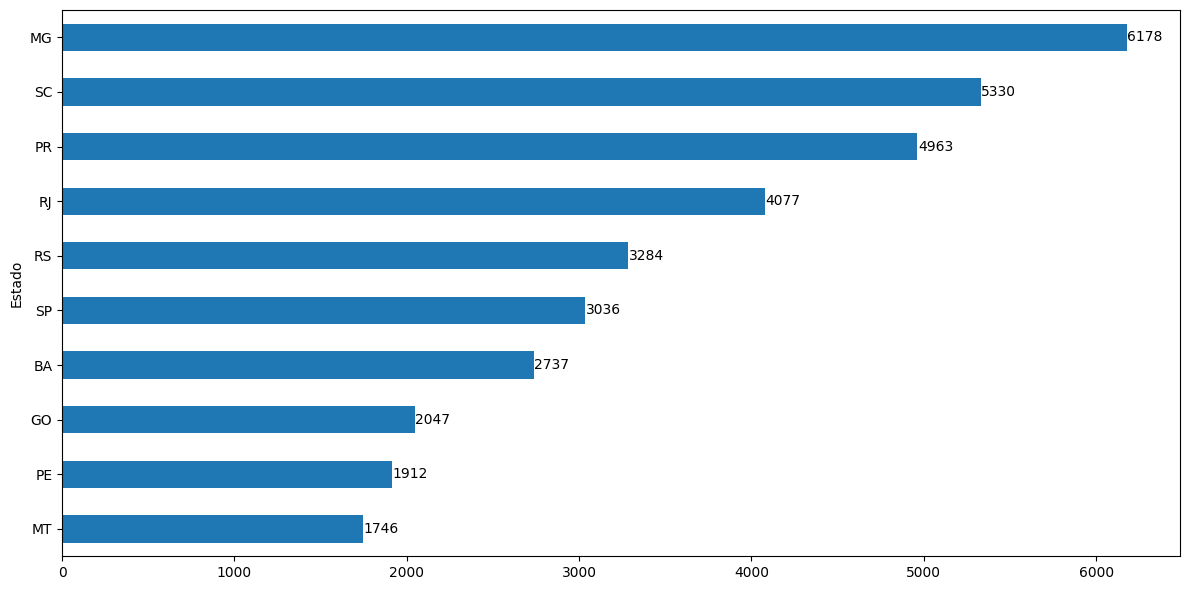

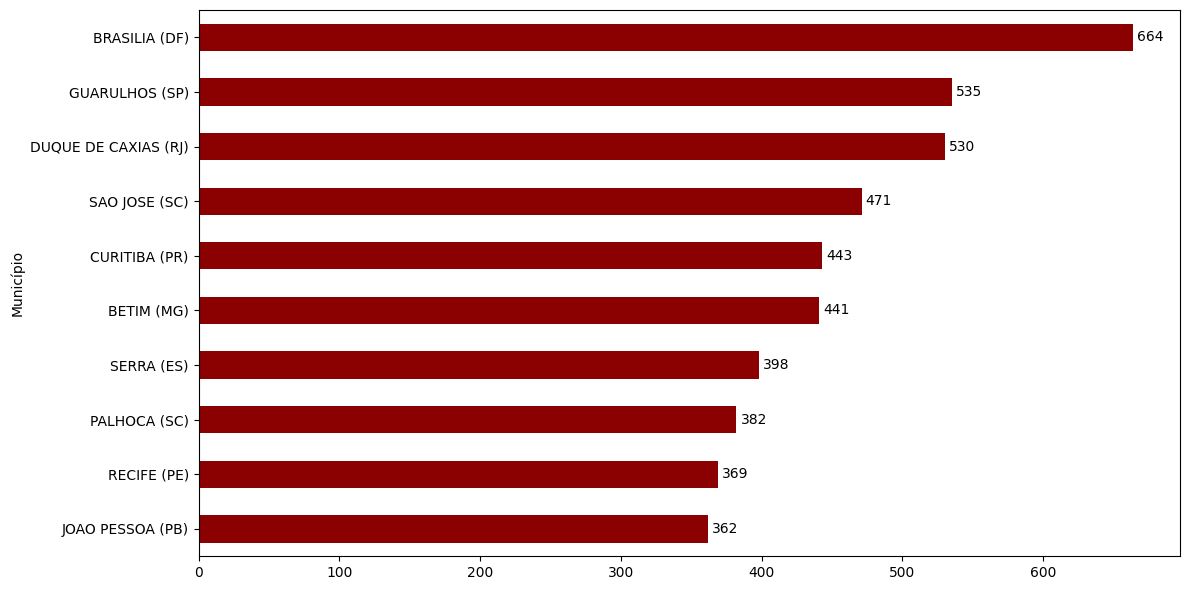

In [18]:
import matplotlib.pyplot as plt

# Quais são os estados e cidades com o maior número de acidentes?
top_ufs = df_cleaned['uf'].value_counts().head(10)
top_cidades = df_cleaned['municipio'].value_counts()

# Gráfico 1: Estados com mais acidentes
plt.figure(figsize=(12, 6))
top_ufs.sort_values().plot(kind='barh', ylabel='Estado')

# Adicionar valores exatos nas barras
for i, v in enumerate(top_ufs.sort_values()):
    plt.text(v + 3, i, str(v), va='center')

plt.tight_layout()
plt.show()

# Gráfico 2: Cidades com mais acidentes
plt.figure(figsize=(12, 6))
top_cidades.head(10).sort_values().plot(kind='barh', ylabel='Município', color='darkred')

# Adicionar valores exatos nas barras
for i, v in enumerate(top_cidades.head(10).sort_values()):
    plt.text(v + 3, i, str(v), va='center')

plt.tight_layout()
plt.show()

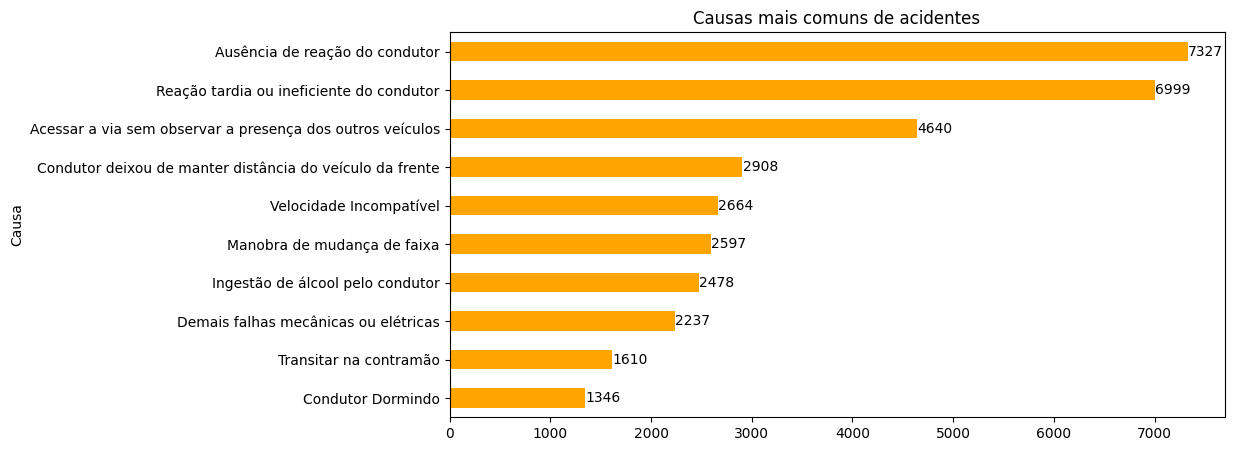

In [19]:
# Qual a causa mais comum de acidentes?
top_causas = df_cleaned['causa_acidente'].value_counts().head(10)
top_causas

# Gráfico de causas
plt.figure(figsize=(10, 5))
top_causas.sort_values().plot(kind='barh', title='Causas mais comuns de acidentes', ylabel='Causa', color='orange')
# plt.tight_layout()

# Add exact values on bars
for i, v in enumerate(top_causas.sort_values()):
    plt.text(v + 3, i, str(v), va='center')
    

plt.show()



In [20]:
# Qual a média de mortos, feridos por tipo de acidente? (tabela)
df_means = df_cleaned.groupby('causa_acidente').agg({'mortos': 'mean', 'feridos': 'mean'})

df_means['total_acidentes'] = df_cleaned['causa_acidente'].value_counts()

df_means = df_means.sort_values(by='total_acidentes', ascending=False)

df_means[['mortos', 'feridos']] = df_means[['mortos', 'feridos']].apply(lambda x: x.round(3))

df_means = df_means.head(10)
df_means

,mortos,feridos,total_acidentes
causa_acidente,,,
Ausência de reação do condutor,0.072,1.096,7327
Reação tardia ou ineficiente do condutor,0.055,1.126,6999
Acessar a via sem observar a presença dos outros veículos,0.061,1.225,4640
Condutor deixou de manter distância do veículo da frente,0.022,1.138,2908
Velocidade Incompatível,0.111,1.190,2664
Manobra de mudança de faixa,0.042,1.216,2597
Ingestão de álcool pelo condutor,0.063,0.883,2478
Demais falhas mecânicas ou elétricas,0.018,0.711,2237
Transitar na contramão,0.396,1.406,1610


In [21]:
# Export df_means into a csv file
df_means.to_csv('causa_acidente_means.csv', sep=';')

In [22]:
# Group by dia_semana and count number of accidents
df_dia_semana = df_cleaned['dia_semana'].value_counts().sort_index
df_dia_semana

# 22298 = finais de semana


<bound method Series.sort_index of dia_semana
sábado           7513
domingo          7472
sexta-feira      7313
segunda-feira    6608
quarta-feira     6240
quinta-feira     6231
terça-feira      5815
Name: count, dtype: int64>

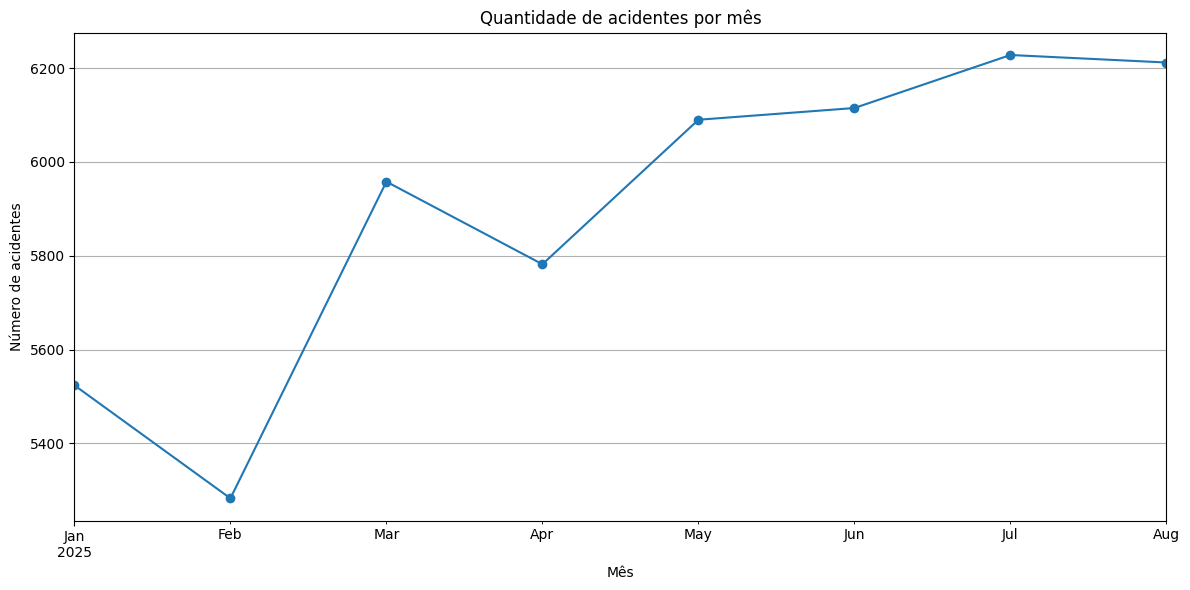

In [23]:
# Convert data column to datetime, format yyyy-mm-dd
df_cleaned['data'] = pd.to_datetime(df_cleaned['data'], format='%Y-%m-%d')

# Gráfico de linha com a quantidade de acidentes por mês
df_acidentes_por_mes = df_cleaned['data'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(12, 6))
df_acidentes_por_mes.plot(kind='line', marker='o')
plt.title('Quantidade de acidentes por mês')
plt.ylabel('Número de acidentes')
plt.xlabel('Mês')
plt.grid()
plt.tight_layout()
plt.show()

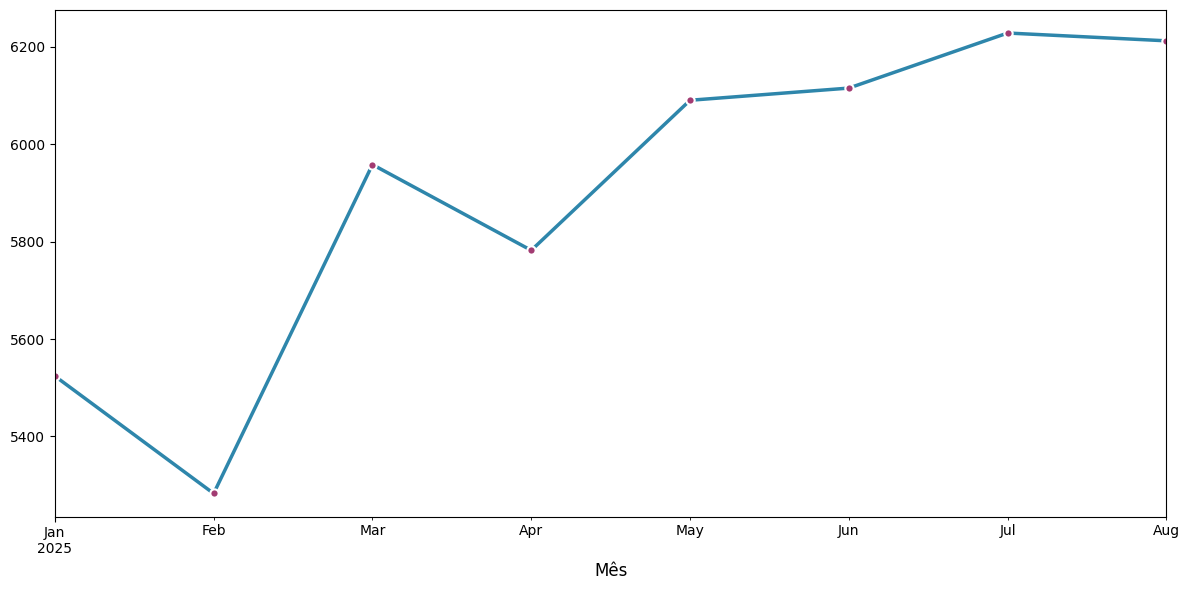

In [24]:
# Convert data column to datetime, format yyyy-mm-dd
df_cleaned['data'] = pd.to_datetime(df_cleaned['data'], format='%Y-%m-%d')

# Gráfico de linha com a quantidade de acidentes por mês
df_acidentes_por_mes = df_cleaned['data'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12, 6))
df_acidentes_por_mes.plot(
    kind='line', 
    marker='o', 
    linewidth=2.5,
    markersize=6,
    color='#2E86AB',
    markerfacecolor='#A23B72',
    markeredgecolor='white',
    markeredgewidth=1.5
)

plt.xlabel('Mês', fontsize=12)
plt.grid(alpha=0, linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

In [26]:
# Filter only uf == 'PR'

df_pr = df_cleaned[df_cleaned['uf'] == 'PR']
df_pr.head()

# Export to a new CSV file
df_pr.to_csv('prf_acidentes_pr.csv', sep=';', index=False)